In [ ]:
import pandas as pd
import os
import numpy as np
import xarray as xr
import netCDF4
import matplotlib.pyplot as plt


In [ ]:
os.chdir("/home/agritech/Working_Directory/Thèses/Dossier_ma_These/Data/map_faidherbia")

In [ ]:
os.listdir()

['modified_map2015PFT3.nc',
 'map_TreeCrop_2015.nc',
 'redlist_species_data_63e55ebc-32d5-4975-9069-e0969caec144.zip',
 'PFTmap_2015.nc',
 'T19375471A146219700.jpg',
 '10.2305_IUCN.UK.2019-2.RLTS.T19375471A146219700.en.pdf',
 'map2015PFT3.nc',
 'FG2-mapTest_19030101_19031231_1M_stomate_history.nc',
 'PFTmapSpinupEG2015.nc']

In [ ]:
#Coordinate SN-Niakhar 
LON_WEST = -18 #-17
LAT_NORTH = 16
LAT_SOUTH = 14
LON_EAST = -16

In [ ]:
import shutil

source_file = 'PFTmap_2015.nc'
# Define the permission value (0o755 for a+rx)
permissions = 0o755

# Use os.chmod to set the file permissions
os.chmod(source_file, permissions)

destination_file = 'copy_of_PFTmap_2015.nc'

shutil.copy(source_file, destination_file)


'copy_of_PFTmap_2015.nc'

In [ ]:

if os.path.exists(destination_file) :
    nc = netCDF4.Dataset(destination_file , "r+")
else:
    print(f"The file '{destination_file}' does not exist.")

In [ ]:
nc

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    date: 29/11/2017 18:19
    web: https://orchidas.lsce.ipsl.fr/dev/LCCCI.php
    contact: V.Bastrikov (vladislav.bastrikov@lsce.ipsl.fr), P.Peylin (philippe.peylin@lsce.ipsl.fr), N.Vuichard (nicolas.vuichard@lsce.ipsl.fr)
    resolution: Regular lat/lon 0.25-degree
    description: ORCHIDEE PFT map based on the ESA CCI Land Cover map v2.0.7b for 2010 aggregated by the user-tool v3.13 with the cross-walking table v2.4, followed by historical reconstrution using G. Hurtt data LU2v2h with merging rules v2.0
    history: Fri Apr 27 17:45:04 2018: ncks -4 /ccc/work/cont003/igcmg/igcmg/IGCM/SRF/PFTMAPS/CMIP6/ESA-LUH2v2/historical/15PFT.v1/PFTmap_2015.nc /ccc/work/cont003/igcmg/igcmg/IGCM/SRF/PFTMAPS/CMIP6/ESA-LUH2v2/historical/15PFT.v2/PFTmap_2015.nc
    NCO: 4.4.8
    dimensions(sizes): lat(720), lon(1440), time_counter(1), veget(15)
    variables(dimensions): float64 lat(lat), float64 lon(lon), float32

In [ ]:
lat, lon = nc.variables['lat'], nc.variables['lon']
latvals = lat[:]; lonvals = lon[:] # extract lat/lon values (in degrees) to numpy arrays

In [ ]:
def geo_idx(dd, dd_array):
  import numpy as np
  """
  search for nearest decimal degree in an array of decimal degrees and return the index.
  np.argmin returns the indices of minium value along an axis.
  so subtract dd from all values in dd_array, take absolute value and find index of minimum.
  """
  geo_idx = (np.abs(dd_array - dd)).argmin()
  return geo_idx

In [ ]:
LON_WEST_idx = geo_idx(LON_WEST, lonvals)
LAT_NORTH_idx = geo_idx(LAT_NORTH, latvals)
LAT_SOUTH_idx = geo_idx(LAT_SOUTH, latvals)
LON_EAST_idx = geo_idx(LON_EAST, lonvals)
LON_WEST_idx, LAT_NORTH_idx, LAT_SOUTH_idx, LON_EAST_idx

(647, 295, 303, 655)

In [ ]:
nc.variables["maxvegetfrac"][0, 2, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] 

masked_array(
  data=[[--, --, --, --, --, 0.1369943916797638, 0.15300852060317993,
         0.1786242425441742],
        [--, --, --, --, --, 0.11819858103990555, 0.1369943916797638,
         0.11039017140865326],
        [--, --, --, --, 0.10030565410852432, 0.11655457317829132,
         0.09942588210105896, 0.06096185743808746],
        [--, --, --, 0.07506589591503143, 0.09495972096920013,
         0.10030565410852432, 0.1295214742422104, 0.12166076898574829],
        [--, --, 0.0706736147403717, 0.05908017233014107,
         0.07506589591503143, 0.10951396822929382, 0.11844504624605179,
         0.031628675758838654],
        [--, --, 0.09067510068416595, 0.0706736147403717,
         0.03151968866586685, 0.07162348926067352, 0.027119839563965797,
         0.007242052350193262],
        [--, --, 0.09067510068416595, 0.11065362393856049,
         0.11404486745595932, 0.03570948913693428, 0.033966802060604095,
         0.00903244037181139],
        [--, --, 0.11065362393856049, 0.112

In [ ]:
prop_tree = 0.0584
prop_crop = 1 - prop_tree

if prop_crop + prop_tree != 1.0:
    print(f"Sum should be equal to 1.0 instead of : {prop_crop + prop_tree}")
else:
    for ipft in range(0,15):
        if ipft == 2:
            nc.variables["maxvegetfrac"][0, ipft, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] = prop_tree
        elif ipft == 12:
            nc.variables["maxvegetfrac"][0, ipft, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] = prop_crop
        else:
            nc.variables["maxvegetfrac"][0, ipft, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] = 0

In [ ]:
nc.variables["maxvegetfrac"][0, 2, LAT_NORTH_idx:LAT_SOUTH_idx, LON_WEST_idx:LON_EAST_idx] 

masked_array(
  data=[[0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584],
        [0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584, 0.0584]],
  mask=False,
  fill_value=1e+20,
  dtype=float32)

In [ ]:
nc.close()

#### Second method

In [ ]:

# Open the NetCDF file
dataset = xr.open_dataset(destination_file, decode_times=False)


# Find the indices for the specified coordinates
lon_indices = np.where((dataset.lon >= LON_WEST) & (dataset.lon <= LON_EAST))[0]
lat_indices = np.where((dataset.lat <= LAT_NORTH) & (dataset.lat >= LAT_SOUTH))[0]

print(lon_indices , lat_indices)


[648 649 650 651 652 653 654 655] [296 297 298 299 300 301 302 303]


In [ ]:
# Define the values to replace for veget=3 and veget=13
prop_tree = 0.0584
prop_crop = 1 - prop_tree

replace_values = {
    3: prop_tree,
    13: prop_crop,
}

# Iterate through veget values and update "maxvegetfrac" variable
for veget, replace_value in replace_values.items():
    # Replace values for the specified coordinates
    dataset['maxvegetfrac'][0, veget - 1, lat_indices, lon_indices] = replace_value

# Replace all other veget values with 0
other_veget_indices = [v - 1 for v in dataset.veget.values if v not in replace_values]
dataset['maxvegetfrac'][0, other_veget_indices, lat_indices, lon_indices] = 0.0

# Save the modified dataset back to a new NetCDF file
output_file = "modified_map2015PFT3.nc"
dataset.to_netcdf(output_file)

# Close the dataset
dataset.close()

print("Modification complete. Saved as", output_file)

Modification complete. Saved as modifiedv2_map2015PFT3.nc


In [ ]:
other_veget_indices

[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]

In [ ]:
print(lon_indices-1, lat_indices-1)

[651 652 653 654] [299 300 301 302]


In [ ]:
dataset = xr.open_dataset("map2015PFT3.nc", decode_times=False)

In [ ]:
dataset["maxvegetfrac"].sel(lat=slice(LAT_NORTH, LAT_SOUTH), lon=slice(LON_WEST, LON_EAST), veget=3).to_dataframe().reset_index()

,time_counter,lat,lon,veget,maxvegetfrac
0,2015.0,15.875,-17.875,3,1.0
1,2015.0,15.875,-17.625,3,1.0
2,2015.0,15.875,-17.375,3,1.0
3,2015.0,15.875,-17.125,3,1.0
4,2015.0,15.875,-16.875,3,1.0
...,...,...,...,...,...
59,2015.0,14.125,-17.125,3,1.0
60,2015.0,14.125,-16.875,3,1.0
61,2015.0,14.125,-16.625,3,1.0
62,2015.0,14.125,-16.375,3,1.0


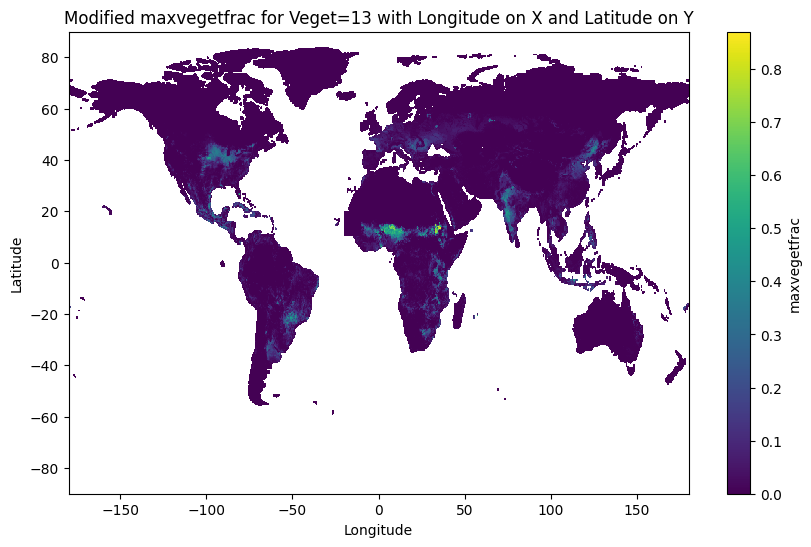

In [ ]:
# Extract the modified maxvegetfrac variable
maxvegetfrac = dataset['maxvegetfrac'][0].values  # Assuming the first time step

# Get latitude and longitude values
latitudes = dataset.lat.values
longitudes = dataset.lon.values

# Choose a specific veget value to plot (e.g., veget=3)
veget_value = 13
veget_index = veget_value - 1  # Convert to zero-based index

# Extract the values for the selected veget value
veget_data = maxvegetfrac[veget_index, :, :]

# Create a plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(longitudes, latitudes, veget_data, cmap='viridis')
plt.colorbar(label='maxvegetfrac')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Modified maxvegetfrac for Veget={veget_value} with Longitude on X and Latitude on Y')

# Show the plot
plt.show()








##### Groundwater checks

In [ ]:
gw = xr.open_mfdataset('/home/agritech/Working_Directory/Thèses/Dossier_ma_These/Data/SWC_nc_data/VWC_obs_GAPFILLED_Nkr_solay_full_120_*.nc')

In [ ]:
gw.data_vars

Data variables:
    moistc_1  (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_2  (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>
    moistc_3  (time_counter, z, lat, lon) float32 dask.array<chunksize=(366, 120, 1, 1), meta=np.ndarray>

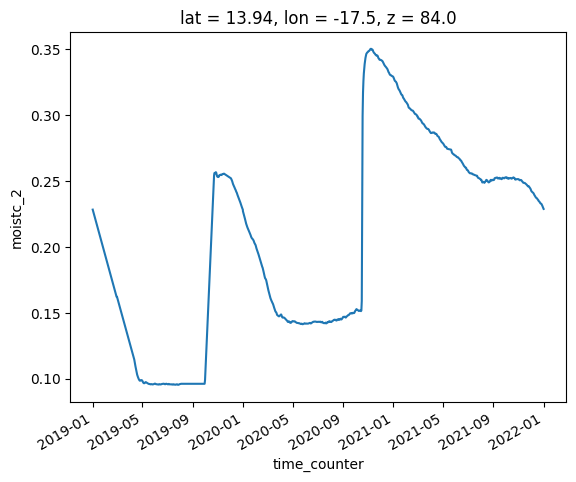

In [ ]:
gw.moistc_2.sel(z=84).plot()